### Understanding the Vehicle Routing Problem with Time Windows (VRPTW)

Each customer has:
- A specific demand (how much load needs to be delivered or picked up).
- A time window during which service must start.
- A fixed service duration.

Each vehicle has:
- A limited capacity.
- A route that must begin and end at the depot.

The goal is to **minimize the total travel distance (or time)** while ensuring all customers are served within their allowed time windows and capacity limits.

**Key constraints:**

1. **Customer visitation:**  
   Every customer must be visited exactly once by exactly one vehicle.

2. **Route continuity:**  
   If a vehicle visits a customer, it must also leave that customer, forming a continuous route that starts and ends at the depot.

3. **Vehicle capacity:**  
   The total demand served by any vehicle cannot exceed its maximum load capacity.

4. **Time windows:**  
   Service at each customer must begin within their allowed time window.  
   If a vehicle arrives early, it waits until the window opens.

5. **Service and travel timing:**  
   The start time at the next customer must account for the travel time and service duration at the previous one.  
   (This ensures that routes are both spatially and temporally feasible.)


In [31]:
import csv
import io
import math
import matplotlib.pyplot as plt
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

# For displaying plots inline in the notebook
%matplotlib inline
import pandas as pd

### The Data Model
Instead of a real database, we use a synthetic dataset for a Vehicle Routing Problem (VRP) using OR-Tools.  

**CSV structure:**

| Column | Description |
|:--------|:-------------|
| `customer_id` | Unique ID of each location (0 is the depot) |
| `x`, `y` | Coordinates of the customer on a 2D plane |
| `demand` | Amount of load that customer requires |
| `time_window_start`, `time_window_end` | Allowed time window for visiting the customer |
| `service_time` | Time required to serve that customer |

Example row:
1,45,68,10,912,967,10

→ Customer 1 is at (45, 68), needs 10 units of demand, should be visited between time 912–967, and takes 10 time units to serve.

3. A full **Euclidean distance matrix** is computed between all locations.
4. Finally, everything is combined into a dictionary called `data`. This `data` dictionary is then used by OR-Tools to define and solve the routing problem.

In [32]:
def compute_euclidean_distance(loc1, loc2):
    """Calculates the rounded Euclidean distance between two points."""
    # We round to an integer because OR-Tools works with integers for
    # travel time and distance. This implies a speed of 1 unit dist / 1 unit time.
    return int(math.sqrt((loc1[0] - loc2[0])**2 + (loc1[1] - loc2[1])**2))

def create_data_model():
    """Stores the data for the problem."""
    
    # --- 1. Load Our Synthetic Dataset ---
    # We embed the CSV data as a string for a self-contained example.
    csv_data = """customer_id,x,y,demand,time_window_start,time_window_end,service_time
0,40,50,0,0,1236,0
1,45,68,10,912,967,10
2,45,70,30,825,870,10
3,42,66,10,65,146,10
4,42,68,10,727,782,10
5,42,69,20,614,659,10
6,40,69,10,150,221,10
7,40,66,10,621,682,10
8,38,68,20,812,867,10
9,38,70,10,90,161,10
10,35,66,10,308,379,10
"""
    
    locations = []
    demands = []
    time_windows = []
    service_times = []

    f = io.StringIO(csv_data)
    reader = csv.reader(f)
    next(reader)  # Skip the header row
    
    for row in reader:
        locations.append((int(row[1]), int(row[2])))
        demands.append(int(row[3]))
        time_windows.append((int(row[4]), int(row[5])))
        service_times.append(int(row[6]))
    # --- 2. Calculate Distance Matrix ---
    num_locations = len(locations)
    distance_matrix = [[0] * num_locations for _ in range(num_locations)]
    for i in range(num_locations):
        for j in range(num_locations):
            distance_matrix[i][j] = compute_euclidean_distance(locations[i], locations[j])

    # --- 3. Define Global Problem Parameters ---
    data = {}
    data['locations'] = locations
    data['demands'] = demands
    data['time_windows'] = time_windows
    data['service_times'] = service_times
    data['distance_matrix'] = distance_matrix
    data['num_vehicles'] = 2
    data['vehicle_capacities'] = [100] * data['num_vehicles']  # List, one for each vehicle
    data['depot'] = 0 # The depot is location 0
    
    return data

create_data_model()["vehicle_capacities"]

[100, 100]

In [33]:
# Display the data as a DataFrame for better visualization

data = create_data_model()
df = pd.DataFrame({
    'customer_id': range(len(data['locations'])),
    'x': [loc[0] for loc in data['locations']],
    'y': [loc[1] for loc in data['locations']],
    'demand': data['demands'],
    'time_window_start': [tw[0] for tw in data['time_windows']],
    'time_window_end': [tw[1] for tw in data['time_windows']],
    'service_time': data['service_times']
})

df

,customer_id,x,y,demand,time_window_start,time_window_end,service_time
0,0,40,50,0,0,1236,0
1,1,45,68,10,912,967,10
2,2,45,70,30,825,870,10
3,3,42,66,10,65,146,10
4,4,42,68,10,727,782,10
5,5,42,69,20,614,659,10
6,6,40,69,10,150,221,10
7,7,40,66,10,621,682,10
8,8,38,68,20,812,867,10
9,9,38,70,10,90,161,10


### Modelling the Constraints 

# 1. Create Routing Manager and Model

   The `RoutingIndexManager` lets you translate between:
   - External (data-based) indices → what you see in your CSV
   - Internal solver indices → what OR-Tools uses internally

   `pywrapcp.RoutingModel`

    - It uses the manager to understand the problem structure and allows you to:
    - Register callbacks (for distance, time, or cost between nodes)
    - Add constraints (capacity, time windows, etc.)
    - Set the search strategy and cost function
    - Run the solver to find optimal or near-optimal routes


In [34]:
# 1. Create Routing Manager and Model

manager = pywrapcp.RoutingIndexManager(
    len(data['distance_matrix']), data['num_vehicles'], data['depot']
)  # The manager maps our "customer IDs" to the solver's internal indices.

routing = pywrapcp.RoutingModel(manager) # Register callbacks (for distance, time, or cost between nodes), 
#Add constraints (capacity, time windows, etc.) andSet the search strategy and cost function

#### 1. Defining the Cost Function (Objective)

In OR-Tools, the objective function is defined through a **transit callback** — a user-defined function that tells the solver the "cost" of traveling from one node to another. 

`distance_callback(from_index, to_index)`

- OR-Tools internally uses its own node indices for optimization. We convert these to our dataset’s node IDs using `manager.IndexToNode()`.

- The function returns the distance value between the two nodes from our precomputed `distance_matrix`.

`routing.RegisterTransitCallback(distance_callback)`

- Registers our callback with the solver so that it can call this function whenever it needs to evaluate the cost of moving from one node to another.

`routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)`

- Sets the registered callback as the cost evaluator for all vehicles.
- This tells the solver that the objective is to minimize the total cost 

In [35]:
# 2. Define Cost (Objective Function)
def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return data['distance_matrix'][from_node][to_node]

transit_callback_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

#### 2. Defining the Demand Callback and Capacity Constraints

`def demand_callback(from_index):`

- The solver needs a way to ask, **"How much 'load' do I add when I visit this location?"**  
  The callback returns the corresponding demand value from our precomputed dataset.

- The solver passes internal indices (`from_index`, `to_index`), which we convert back to our own node IDs using `manager.IndexToNode()`.

---

`routing.AddDimensionWithVehicleCapacity(...)`

It takes **5 arguments**:

1. **demand_callback_index**:  
   Tells the dimension to use our registered `demand_callback` to calculate the running total.  
   At every stop, it adds the value from this callback.

2. **0 (slack)**:  
   We set it to 0 because capacity is a hard limit.

3. **data['vehicle_capacities']**:  
   This is the list of maximum values (e.g., `[100, 100]`).  
   The solver automatically ensures that the running total for any vehicle never exceeds its corresponding limit.

4. **True (start_cumul_at_zero)**:  
   This forces all vehicles to start at the depot (node 0) with a load of 0.

5. **'Capacity'**:  
   A human-readable name for this dimension, used for debugging and printing results.


In [36]:
# 3. Add Capacity Constraint (Dimension)
def demand_callback(from_index):
    from_node = manager.IndexToNode(from_index)
    return data['demands'][from_node]

demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
routing.AddDimensionWithVehicleCapacity(
    demand_callback_index,
    0,  # slack (0 = no waiting for capacity)
    data['vehicle_capacities'],  # vehicle capacities
    True,  # start cumul at 0
    'Capacity'
) #keeps a running total of demand along each route and prevents any vehicle from exceeding its capacity limit


True

#### Part 1: The `time_callback` (Defining "Transit")

- This function defines the **"cost" of traveling between two nodes** in units of time.  
- The **time cost** is calculated as: `service_time + travel_time`.  
- In other words, the minimum time that must pass between starting service at customer **I** and arriving at customer **J** is the time it takes to **service I** plus the time it takes to **travel from I to J**.

---

#### Part 2: `routing.AddDimension` (Creating the "Time" Tracker)

- This creates the main **"Dimension"** object named `'Time'`.  
- **time_callback_index**: Tells the "stopwatch" to use our `time_callback` (from Part 1) to calculate how much time passes for each leg of the journey.  
- **1000 (slack_max)**: By setting this to a large number (1000), we tell the solver it is allowed to wait as long as needed to meet a time window.  
- **1000 (capacity)**: It means the `'Time'` dimension's value can never exceed 1000 for any vehicle.  
- **True (fix_start_cumul_to_zero)**: This ensures all vehicle "stopwatches" start at **0** at the depot.


In [37]:
# 4. Add Time Window Constraint (Dimension)
def time_callback(from_index, to_index):
    """Returns the travel time + service time between two nodes."""
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    service = data['service_times'][from_node]
    travel = data['distance_matrix'][from_node][to_node]
    return service + travel

time_callback_index = routing.RegisterTransitCallback(time_callback)
routing.AddDimension(
    time_callback_index,
    1000,  # slack_max (max allowed waiting time per stop)
    1000,  # capacity (max total time per vehicle)
    True,  # fix_start_cumul_to_zero
    'Time'
)



True

#### Part 3: The SetRange Loop (Enforcing Customer Time Windows)

- `time_dimension.CumulVar(index)`:  
  Represents the cumulative value of the `'Time'` dimension at a specific index (customer).  
  Because we allowed **"slack" (waiting)** in Part 2, this value is **not the arrival time**, but the **Service Start Time**.

- `.SetRange(time_window[0], time_window[1])`:  
  We are telling the solver:  
  > "For this customer, the Service Start Time (`CumulVar`) must be greater than or equal to `time_window[0]` **AND** less than or equal to `time_window[1]`."

This loop iterates through every customer and adds this **SetRange constraint**,  
including one for the **depot** to ensure all routes start and end within the operating day.

In [38]:
# Get the Time Dimension object and apply time windows
time_dimension = routing.GetDimensionOrDie('Time')
for location_idx, time_window in enumerate(data['time_windows']):
    if location_idx == data['depot']:
        continue
    index = manager.NodeToIndex(location_idx)
    time_dimension.CumulVar(index).SetRange(time_window[0], time_window[1])
    
# Set time window for the depot
depot_idx = data['depot']
index = manager.NodeToIndex(depot_idx)
time_dimension.CumulVar(index).SetRange(
    data['time_windows'][depot_idx][0],
    data['time_windows'][depot_idx][1]
)


# Add start/end time constraints for each vehicle
for i in range(data['num_vehicles']):
    routing.AddVariableMaximizedByFinalizer(
        time_dimension.CumulVar(routing.Start(i))
    )
    routing.AddVariableMinimizedByFinalizer(
        time_dimension.CumulVar(routing.End(i))
    )


#### 5. Set Search Strategy

This part configures the **two-step process** the solver will use:

`DefaultRoutingSearchParameters()`:  
Creates a **settings object** that we will now customize.

---

- **first_solution_strategy**:  
  This tells the solver how to get its **first guess**.

- **PATH_CHEAPEST_ARC**:  
  This is a **"greedy" algorithm**. It builds the routes by iteratively adding the "cheapest" (shortest distance) trip possible.

---

**local_search_metaheuristic**

- **"Local Search"**:  
  This means the solver takes the first solution and then tries to **improve it** using metaheuristic optimization methods.

---

**time_limit.seconds**:  
This defines the **stopping criterion** — how long the solver is allowed to keep searching for improvements.

---

#### 6. Solve the Problem

`routing.SolveWithParameters(...)`:  
This is the **"Go" button**.

- It tells the routing model (which holds all our constraints and the objective) to **start the search process** using the `search_parameters`.

---

The solver will now:

- Run **PATH_CHEAPEST_ARC** — this takes just a few milliseconds.  
- Run **GUIDED_LOCAL_SEARCH** — this uses the remaining time (e.g., 30 seconds) to **continuously improve** the solution.


In [39]:

    
# 5. Set Search Strategy
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
search_parameters.local_search_metaheuristic = (
    routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
)
search_parameters.time_limit.seconds = 30  # Set a 30-second time limit


# 6. Solve the Problem
print("Solving... (may take up to 30 seconds)")
solution = routing.SolveWithParameters(search_parameters)

Solving... (may take up to 30 seconds)


In [40]:
def print_solution(data, manager, routing, solution):
    """Prints the solution to the console."""
    print(f'Objective (Total Distance): {solution.ObjectiveValue()} units\n')
    
    time_dimension = routing.GetDimensionOrDie('Time')
    total_time = 0
    total_load = 0
    
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        plan_output = f'Route for Vehicle {vehicle_id}:\n'
        route_distance = 0
        route_load = 0
        
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            
            # Get variables for this node
            route_load += data['demands'][node_index]
            time_var = time_dimension.CumulVar(index)
            time_min = solution.Min(time_var)
            time_max = solution.Max(time_var)
            
            # Format output
            plan_output += (
                f'  {node_index} (Load: {route_load}) '
                f'(Time: {time_min}, {time_max}) ->\n'
            )
            
            # Get distance to next node
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(
                previous_index, index, vehicle_id
            )
            
        # Handle the last node (depot)
        node_index = manager.IndexToNode(index)
        time_var = time_dimension.CumulVar(index)
        plan_output += (
            f'  {node_index} (Load: {route_load}) '
            f'(Time: {solution.Min(time_var)}, {solution.Max(time_var)})\n'
        )
        
        plan_output += f'Distance of the route: {route_distance} units\n'
        plan_output += f'Load of the route: {route_load}\n'
        print(plan_output)
        
        total_time += solution.Min(time_var)
        total_load += route_load
        
    print(f'Total Load of all routes: {total_load}')
    print(f'Total Time of all routes: {total_time}')


def plot_solution(data, manager, routing, solution):
    """Plots the solution on a 2D graph."""
    print("Plotting routes...")
    plt.figure(figsize=(12, 8))
    
    # Plot all locations
    locations = data['locations']
    x = [loc[0] for loc in locations]
    y = [loc[1] for loc in locations]
    plt.scatter(x[1:], y[1:], c='gray', label='Customers')
    
    # Plot the depot (Node 0)
    plt.scatter(x[0], y[0], c='red', marker='*', s=200, label='Depot (0)')
    
    # Add labels
    for i, (xi, yi) in enumerate(locations):
        plt.text(xi + 0.5, yi + 0.5, str(i))

    # Plot the routes
    colors = plt.cm.jet([i / data['num_vehicles'] for i in range(data['num_vehicles'])])
    
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        route_x = []
        route_y = []
        
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            route_x.append(locations[node_index][0])
            route_y.append(locations[node_index][1])
            index = solution.Value(routing.NextVar(index))
        
        # Add the end node (depot)
        node_index = manager.IndexToNode(index)
        route_x.append(locations[node_index][0])
        route_y.append(locations[node_index][1])
        
        # Plot if the route is used
        if len(route_x) > 2: # Only plot routes that do more than Depot -> Depot
            plt.plot(route_x, route_y, color=colors[vehicle_id], 
                     marker='o', markersize=5,
                     label=f'Vehicle {vehicle_id}')

    plt.title('Vehicle Routing Problem with Time Windows')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.grid(True)
    plt.show()
    

Objective (Total Distance): 90 units

Route for Vehicle 0:
  0 (Load: 0) (Time: 0, 0) ->
  10 (Load: 10) (Time: 308, 379) ->
  7 (Load: 20) (Time: 621, 682) ->
  8 (Load: 40) (Time: 812, 812) ->
  0 (Load: 40) (Time: 840, 840)
Distance of the route: 41 units
Load of the route: 40

Route for Vehicle 1:
  0 (Load: 0) (Time: 0, 0) ->
  3 (Load: 10) (Time: 65, 146) ->
  9 (Load: 20) (Time: 90, 161) ->
  6 (Load: 30) (Time: 150, 221) ->
  5 (Load: 50) (Time: 614, 659) ->
  4 (Load: 60) (Time: 727, 782) ->
  2 (Load: 90) (Time: 825, 870) ->
  1 (Load: 100) (Time: 912, 912) ->
  0 (Load: 100) (Time: 940, 940)
Distance of the route: 49 units
Load of the route: 100

Total Load of all routes: 140
Total Time of all routes: 1780
Plotting routes...


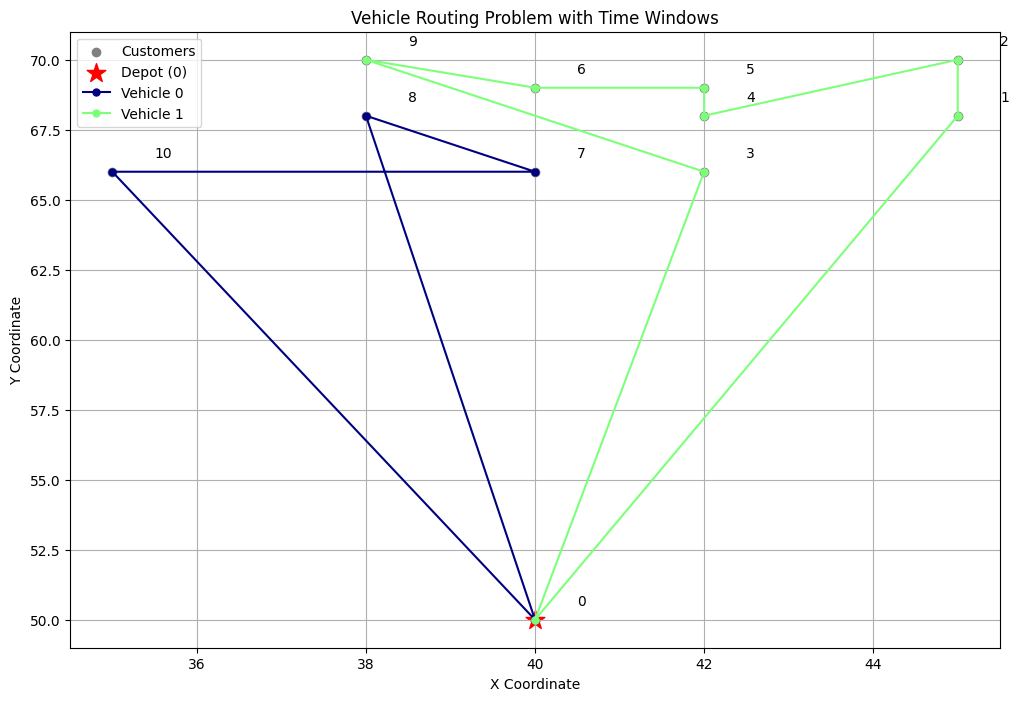

In [41]:

# 7. Print and Plot Solution
if solution:
    print_solution(data, manager, routing, solution)
    plot_solution(data, manager, routing, solution)
else:
    print('No solution found!')